## 1. Configuração do ambiente

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [16]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [17]:
# bibliotecas para machine learning
import mlflow
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

## 2. Carregando o dataset
### Esquema das variáveis conforme o Kaggle
- Customers who left within the last month: the column is called Churn

- Services that each customer has signed up for: phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies

- Customer account information: how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges

- Demographic info about customers: gender, age range, and if they have partners and dependents

In [18]:
# define o caminho
path = '../../data/raw/ibm-telco-customer-churn.csv'

# carrega os dados
df = pd.read_csv(path)

print(f"Shape dos dados: {df.shape}")
print("\nPrimeiras linhas do dataset:")
df.head()

Shape dos dados: (7043, 21)

Primeiras linhas do dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [19]:
# informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===")
df.info()

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBillin

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Análise Exploratória de Dados (EDA)
### 3.1 Análise de Missing Values
**Objetivo:** Identificar valores ausentes e entender seu padrão de distribuição

In [20]:
print("=== ANÁLISE DE MISSING VALUES ===")

missing_values = pd.DataFrame({
    "Coluna": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values["Missing_Count"] > 0].sort_values(by="Missing_Percentage", ascending=False)

if len(missing_values) > 0:
    print(missing_values)

    plt.figure(figsize=(10,6))
    plt.barh(missing_values["Coluna"], missing_values["Missing_Percentage"], color='coral')
    plt.xlabel('Porcentagem de Valores Ausentes (%)')
    plt.ylabel('Colunas')
    plt.tittle('Porcentagem de Valores Ausentes por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma coluna possui valores ausentes.")

=== ANÁLISE DE MISSING VALUES ===
Nenhuma coluna possui valores ausentes.


### 3.2 Análise da Variável Target
**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===
Contagem de cada classe:
target
0    5174
1    1869
Name: count, dtype: int64

Porcentagem de cada classe:
No Churn: 73.46%
Churn: 26.54%


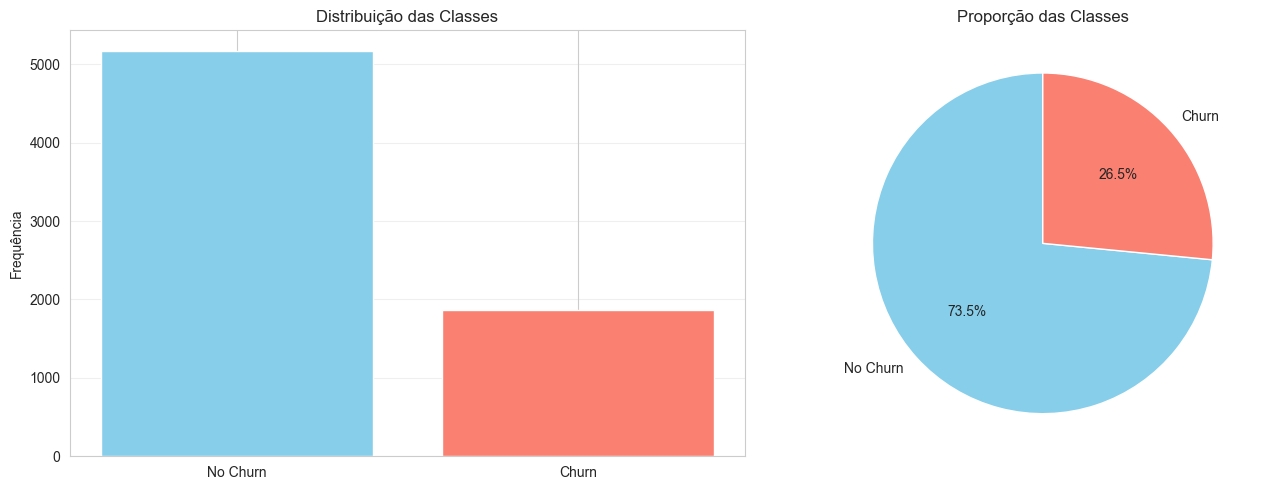


Ratio de desbalanceamento: 0.36
Variável desbalanceada


In [21]:
# renomear a variável target para target
df.rename(columns={'Churn': 'target'}, inplace=True)

# converter target para binário (Yes = 1, No = 0)
df['target'] = df['target'].map({'Yes': 1, 'No': 0}).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem de cada classe:")
print(target_counts)
print("\nPorcentagem de cada classe:")
for idx, pct in target_percentages.items():
    label = 'Churn' if idx == 1 else 'No Churn'
    print(f"{label}: {pct:.2f}%")

# vizualização da distribuição da variável target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# grafico de barras
axes[0].bar(["No Churn", "Churn"], target_counts, color=['skyblue', 'salmon'])
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição das Classes")
axes[0].grid(axis='y', alpha=0.3)

# grafico de setores
axes[1].pie(target_counts.values, labels=["No Churn", "Churn"], 
            autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
axes[1].set_title("Proporção das Classes")

plt.tight_layout()
plt.show()

# avaliar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de desbalanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("Variável desbalanceada")
else:
    print("Variável razoavelmente balanceada")

A variável alvo (target) indica se houve ou não churn. Na visualização, vemos 1869 casos de churn (26,54%) e 5174 no churn (73,46%), o que mostra uma predominância da classe negativa; o ratio entre as classes é de aproximadamente 0,36, indicando um desbalanceamento entre as classes. Isso significa que devemos utilizar a divisão estratificada e técnicas como SMOTE.

### 3.3 Análise de Outliers
**Objetivo:** Identificar valores extremos que podem ser erros de medição ou casos especiais

**Métodos:**
- **Z-Score:** Identifica valores que estão a mais de 3 desvios padrão da média
- **Visualização:** Boxplots para identificação visual

In [22]:
df.select_dtypes(include=[np.number]).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'target'], dtype='str')

In [23]:
# df head com todas as colunas
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


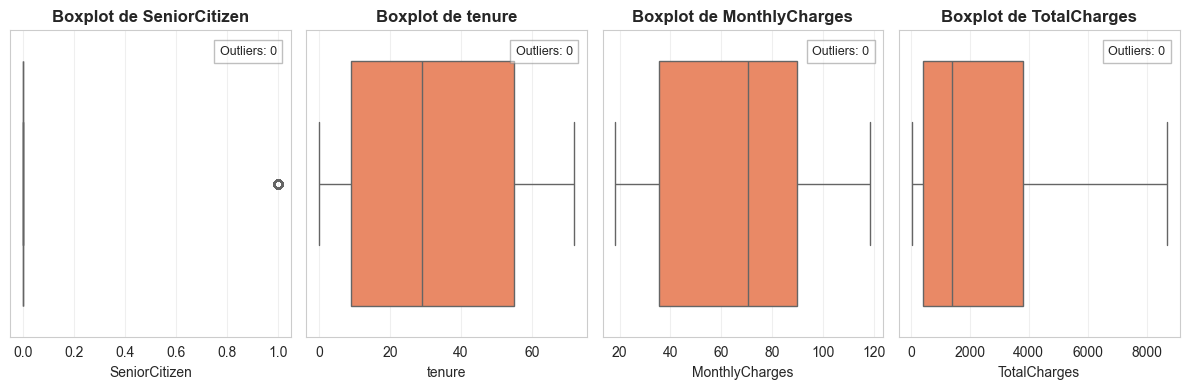

In [24]:
# transformar total charges para numérico float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('target')

n = len(numeric_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, nrows * 4))

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f"Boxplot de {col}",fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))
    
for ax in axes[n:]:
    fig.delxes(ax)

plt.tight_layout()
plt.show()


**Resultados:**
As variáveis não apresentam outliers, tanto pelo boxplot quanto pelo z-score. Por exemplo, tenure não possui outliers estatísticos (z-score > 3) e o boxplot não mostra pontos extremos.

**Conclusão:**
Os dados estão bem distribuídos, sem outliers em tenure, SeniorCitizen e MonthlyCharges. Técnicas simples como capping são suficientes para tratamento, sem necessidade de remoção agressiva.

### 3.4 Análise de Distribuições
**Objetivo:** Entender a distribuição das variáveis numéricas para identificarmos as possíveis assimetrias

In [25]:
distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita') if skewness > 0 else 'Assimétrica à esquerda'
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

        Coluna  Skewness  Kurtosis         Interpretação
 SeniorCitizen     1.834     1.363 Assimétrica à direita
        tenure     0.240    -1.387                Normal
MonthlyCharges    -0.221    -1.257                Normal
  TotalCharges     0.962    -0.232 Assimétrica à direita


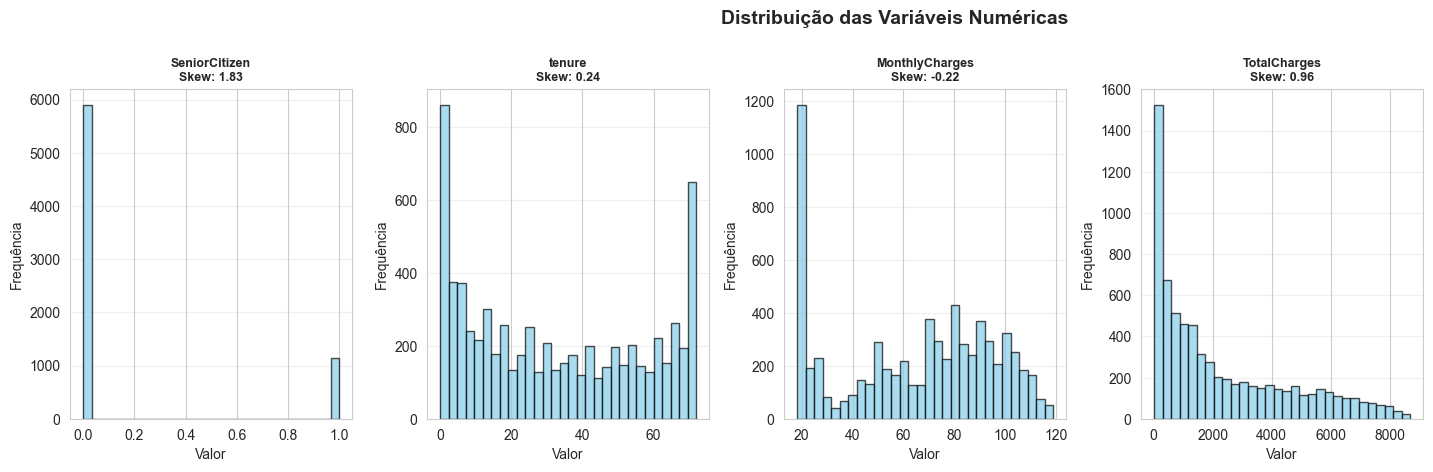

In [26]:
# visualização da distribuição das variáveis numéricas
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}',fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)
    
# remove subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.5 Análise de Correlações Lineares
**Objetivo:** Identificar relações lineares entre variáveis e detectar multicolinearidade

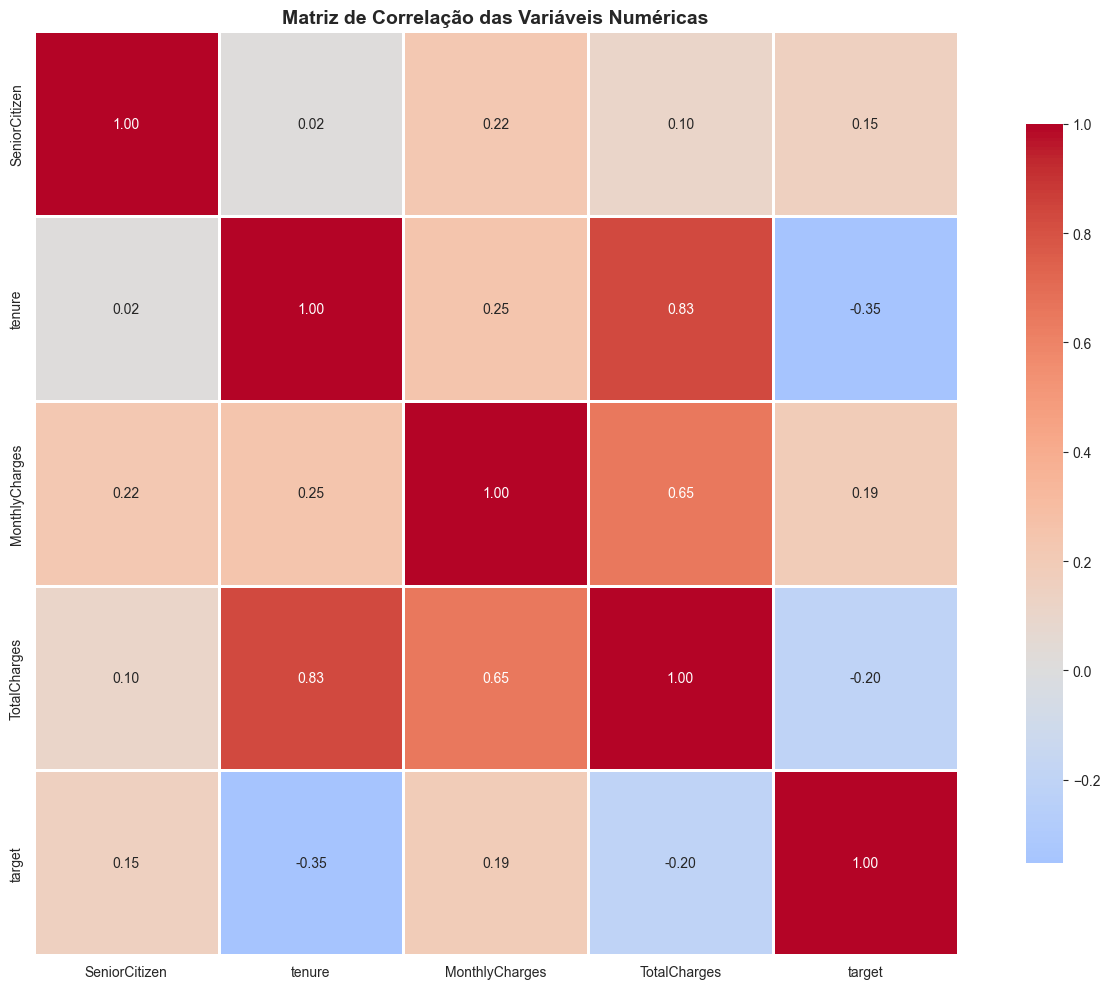

target            1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: target, dtype: float64
Feature 1    Feature 2  Correlation
   tenure TotalCharges        0.826
Alta correlação linear entre as features


In [27]:
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# visualização
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt=".2f", cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# identificar correlações fortes com target
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# identificar pares de features com alta correlação (possiveis multicolinearidades)
high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlation': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlation', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("Alta correlação linear entre as features")
else:
    print("Nenhuma correlação linear alta entre as features")


### 4.2 Codificação de Variáveis Categóricas (One-hot Encoding)
Para que algoritmos de machine learning possam trabalhar com variáveis categóricas, é necessário convertê-las em formato numérico. O método mais comum é o One-hot Encoding, que transforma cada categoria em uma coluna binária (0 ou 1).

**Passos:**

- Identifique as colunas categóricas relevantes (ex.: sex, cp, restecg, slope, thal, dataset).
- Aplique o pd.get_dummies() para criar as variáveis dummies.
- Evite a duplicidade de informação removendo uma categoria de cada variável (drop_first=True), se necessário.

**Observações:**

- O One-hot Encoding aumenta o número de colunas, mas permite que modelos interpretem corretamente as categorias.
- Após a codificação, utilize o novo dataframe (df_encoded) para as etapas de modelagem.

In [32]:
df_clean = df.copy()

# one hot encoding das variaveis categoricas relevantes
categorial_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]
df_encoded = pd.get_dummies(df_clean, columns=categorial_cols, drop_first=True)

print(f'Shape após o One-Hot encoding: {df_encoded.shape}')
df_encoded.head()

Shape após o One-Hot encoding: (7043, 32)


,customerID,tenure,MonthlyCharges,TotalCharges,target,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,29.85,29.85,0,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,34,56.95,1889.50,0,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,2,53.85,108.15,1,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,45,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,9237-HQITU,2,70.70,151.65,1,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


### 4.3 Balanceando as classes
Utilizando a técnica

In [1]:
"""
-> Gabriel
churn_prediction.py
config.py
data_cleaner.py
data_loader.py
feature_engineering.py
main.py
pipeline.py
MVP (regressao logistica e arvore de decisao)

-> Diego
estrutura do projeto
ML Canvas (/docs)
versionamento do código git
"""

'\n-> Gabriel\nchurn_prediction.py\nconfig.py\ndata_cleaner.py\ndata_loader.py\nfeature_engineering.py\nmain.py\npipeline.py\nMVP (regressao logistica e arvore de decisao)\n\n-> Diego\nestrutura do projeto\nML Canvas (/docs)\nversionamento do código git\n'